## **Exploratory Data Analysis & Intro**

### **Goal**

- Analyze customer purchase behaviour.
- Understand the factors affecting customer satisfaction.
- Identify the most revenue-generating products and customer segments.
- Help Business understand which products to promote and which issues customers face.

### **Questions to answers**

- Which products have the highest customer purchase frequency?
- What factors influence customer satisfaction ratings?e highest customer purchase frequency?
- Is there a relationship between customer spending and feedback sentiment?
- Which customer segments contribute the most revenue?
- How does company's revenue change over each day?

### **Load Dataset**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv(r"c:\Users\KHUSHI\Downloads\Customer_Feedback_Analysis.csv.csv")

#Preview the first 10 rows
display(df.head(10))


,Customer_ID,Customer_Name,Gender,Age,Region,Product_Category,Product_Name,Quantity,Unit Price,Purchase_Date,Payement_Method,Rating(1-5),Customer_Feedback
0,C001,Aarav Sharma,Male,27,North,Laptop,Dell Inspiron 15,2,55000,01-Sep-2025,Debit Card,5.0,Excellent Product
1,C002,Priya Verma,Female,32,South,Mobile,Oneplus 11,3,55000,01-Sep-2025,Credit Card,4.0,Very Satisfied
2,C003,Rohit Nair,Male,41,South,Headphones,Boat Rockez 550,1,20000,01-Sep-2025,Cash,4.0,Works Perfectly
3,C004,Kavya Iyer,Female,24,East,Smartwatch,Samsung Galaxy Watch 6,2,35000,01-Sep-2025,UPI,5.0,Excellent Product
4,C005,Manish Reddy,Male,35,North,Laptop,MacBook Air M2,1,120000,01-Sep-2025,UPI,5.0,Excellent Product
5,C006,Neha Mishra,Female,29,West,Mobile,Vivo V27,2,30000,01-Sep-2025,Net Banking,4.0,As Expected
6,C007,Aditya Choudhary,Male,30,North,Mobile,Redmi Note 12 Pro,1,15000,02-Sep-2025,Cash,4.0,Works Perfectly
7,C008,Sneha Pillai,Female,26,East,Headphones,Sony WH-1000XM4,1,25000,02-Sep-2025,UPI,5.0,Excellent Product
8,C009,Rajesh Bansal,Male,45,West,Smartwatch,Apple Watch Series 8,2,45000,02-Sep-2025,UPI,5.0,Great Product
9,C010,Divya Singh,Female,34,South,Accessories,HP Keyboard,3,1200,03-Sep-2025,Cash,3.0,Could be better


### **Data Cleaning**

In [ ]:
#Generated summary statistics to get quick insights(mean,min,max,std)
print("\n Summary Statisitcs")
print(df.describe())


 Summary Statisitcs
             Age    Quantity     Unit Price  Rating(1-5)
count  100.00000  100.000000     100.000000    59.000000
mean    33.31000    1.590000   45212.000000     4.322034
std      5.78695    0.697687   42206.125459     0.752941
min     23.00000    1.000000     800.000000     3.000000
25%     28.75000    1.000000   15000.000000     4.000000
50%     33.00000    1.000000   32500.000000     4.000000
75%     38.00000    2.000000   55000.000000     5.000000
max     46.00000    4.000000  150000.000000     5.000000


In [4]:
#Check dataset info to understand structure(rows,columns,datatypes)
print("Dataset Info")
df.info()


Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer_ID        100 non-null    object 
 1   Customer_Name      100 non-null    object 
 2   Gender             100 non-null    object 
 3   Age                100 non-null    int64  
 4   Region             100 non-null    object 
 5   Product_Category   100 non-null    object 
 6   Product_Name       100 non-null    object 
 7   Quantity           100 non-null    int64  
 8   Unit Price         100 non-null    int64  
 9   Purchase_Date      100 non-null    object 
 10  Payement_Method    100 non-null    object 
 11  Rating(1-5)        59 non-null     float64
 12  Customer_Feedback  59 non-null     object 
dtypes: float64(1), int64(3), object(9)
memory usage: 10.3+ KB


In [ ]:
#Check the total number of missing values
print("\n Total missing values:")
print(df.isnull().sum().sum())

#Check the number of missing values in each column
print("\n Missing values per column:")
print(df.isnull().sum())


 Total missing values:
82

 Missing values per column:
Customer_ID           0
Customer_Name         0
Gender                0
Age                   0
Region                0
Product_Category      0
Product_Name          0
Quantity              0
Unit Price            0
Purchase_Date         0
Payement_Method       0
Rating(1-5)          41
Customer_Feedback    41
dtype: int64


In [3]:
#Unique Values Per Column
unique_counts=df.nunique()
print("\nUnique Value Counts:")
print(unique_counts)


Unique Value Counts:
Customer_ID          100
Customer_Name        100
Gender                 2
Age                   24
Region                 4
Product_Category       5
Product_Name          25
Quantity               4
Unit Price            22
Purchase_Date         30
Payement_Method        6
Rating(1-5)            3
Customer_Feedback     23
dtype: int64


In [3]:
df=df.rename(columns={"Rating(1-5)":"Rating"})
print("\n DataFrame after renaming columns:")
print(df.head())


 DataFrame after renaming columns:
  Customer_ID Customer_Name  Gender  Age Region Product_Category  \
0        C001  Aarav Sharma    Male   27  North           Laptop   
1        C002   Priya Verma  Female   32  South           Mobile   
2        C003    Rohit Nair    Male   41  South       Headphones   
3        C004    Kavya Iyer  Female   24   East       Smartwatch   
4        C005  Manish Reddy    Male   35  North           Laptop   

             Product_Name  Quantity  Unit Price Purchase_Date Payement_Method  \
0        Dell Inspiron 15         2       55000   01-Sep-2025      Debit Card   
1              Oneplus 11         3       55000   01-Sep-2025     Credit Card   
2         Boat Rockez 550         1       20000   01-Sep-2025            Cash   
3  Samsung Galaxy Watch 6         2       35000   01-Sep-2025             UPI   
4          MacBook Air M2         1      120000   01-Sep-2025             UPI   

   Rating  Customer_Feedback  
0     5.0  Excellent Product  
1     

In [11]:
#G)Fill missing ratings with the average rating of the product category
df["Rating"]=df["Rating"].fillna(df.groupby("Product_Category")["Rating"].transform("mean"))
print(df[["Customer_Name","Product_Category","Product_Name","Rating"]])


    Customer_Name Product_Category            Product_Name    Rating
0    Aarav Sharma           Laptop        Dell Inspiron 15  5.000000
1     Priya Verma           Mobile              Oneplus 11  4.000000
2      Rohit Nair       Headphones         Boat Rockez 550  4.000000
3      Kavya Iyer       Smartwatch  Samsung Galaxy Watch 6  5.000000
4    Manish Reddy           Laptop          MacBook Air M2  5.000000
..            ...              ...                     ...       ...
95      Nazia Ali       Smartwatch           Amazfit GTS 4  4.000000
96    Sujoy Manna       Headphones         Sony WH-1000XM4  5.000000
97   Ritwik Satra           Mobile       Redmi Note 12 Pro  4.000000
98  Sneha Cheetri       Headphones         Boat Rockez 550  5.000000
99  Supriyo Majhi           Laptop        Dell Inspiron 15  4.928571

[100 rows x 4 columns]


In [8]:
#H)Convert Purchase_Date column to datetime 
df["Purchase_Date"]=pd.to_datetime(df["Purchase_Date"])
print(df.dtypes)

Customer_ID                  object
Customer_Name                object
Gender                       object
Age                           int64
Region                       object
Product_Category             object
Product_Name                 object
Quantity                      int64
Unit Price                    int64
Purchase_Date        datetime64[ns]
Payement_Method              object
Rating(1-5)                 float64
Customer_Feedback            object
dtype: object


In [22]:
#A)Total revenue of all products
revenue=df["Quantity"].values*df["Unit Price"].values
print("\nTotal Revenue:",np.sum(revenue))


Total Revenue: 5746000


### Q1: Which products have the highest customer purchase frequency?

In [13]:
#D)Top 10 best selling products by quantity
Best_Selling_Products=df.groupby(["Product_Category","Product_Name"])["Quantity"].sum().sort_values(ascending=False).head(10)
print("\n Top 10 best selling products by quantity:")
print(Best_Selling_Products)


 Top 10 best selling products by quantity:
Product_Category  Product_Name          
Accessories       HP Keyboard               14
                  SanDisk 128GB Pendrive    14
Mobile            Vivo V27                  11
Laptop            Dell Inspiron 15           9
Mobile            iphone 15                  9
                  Oneplus 11                 8
                  Redmi Note 12 Pro          8
Smartwatch        Apple Watch Series 8       7
Laptop            ASUS ROG Strix             7
Smartwatch        Noise ColorFit Pro         7
Name: Quantity, dtype: int64


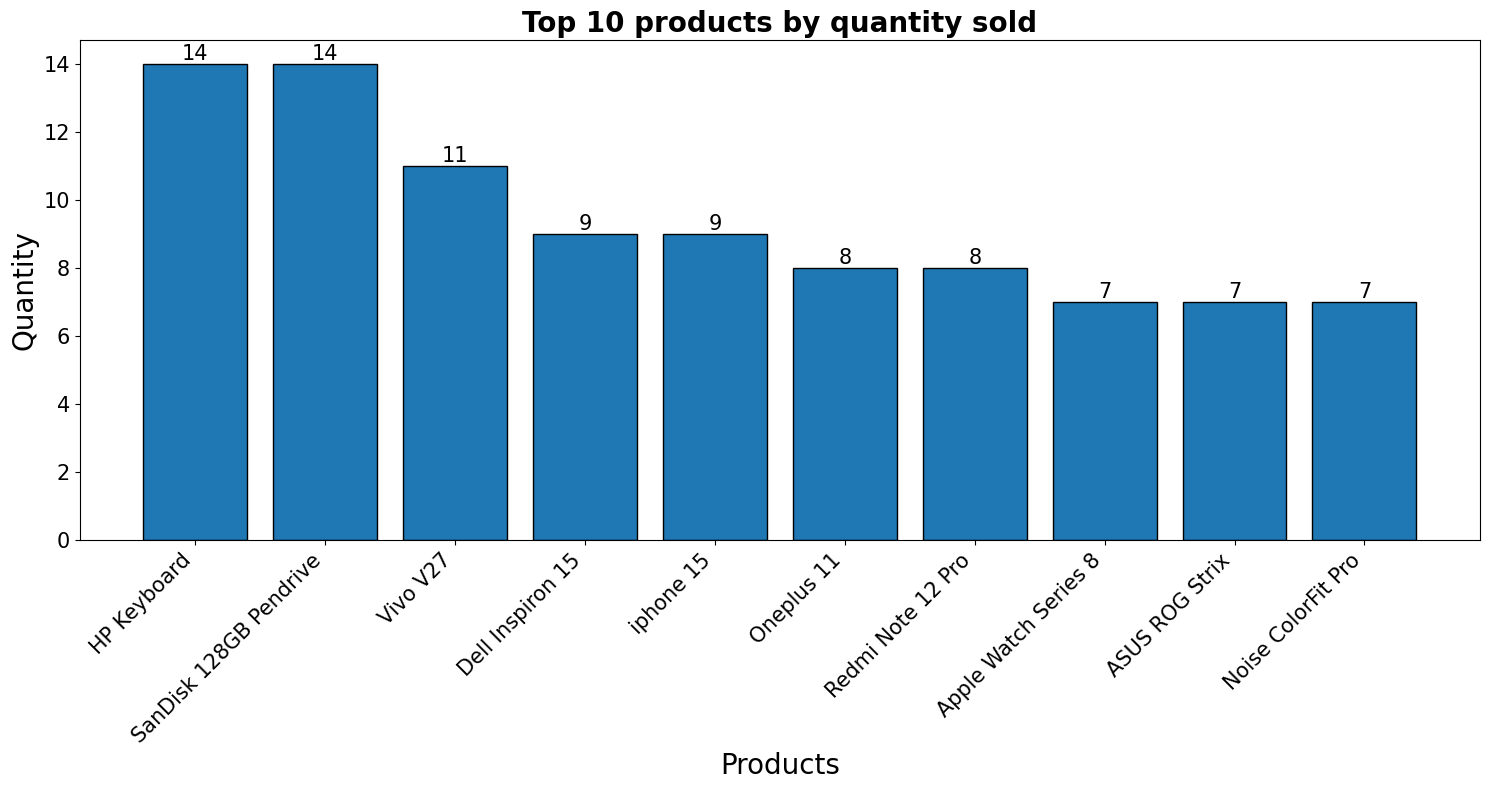

In [27]:
#A)Bar chart of top 10 Products by quantity sold
#Shows which products are most frequently purchased by customers.
Top_Products=(df.groupby("Product_Name")["Quantity"].sum().sort_values(ascending=False).head(10).reset_index())
plt.figure(figsize=(15,8))
bars=plt.bar(Top_Products["Product_Name"],Top_Products["Quantity"],edgecolor="black")
plt.title("Top 10 products by quantity sold",fontsize=20,fontweight="bold")
plt.xlabel("Products",fontsize=20)
plt.ylabel("Quantity",fontsize=20)
plt.xticks(rotation=45,ha="right",fontsize=15)
plt.yticks(fontsize=15)
for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha="center",va="bottom",fontsize=15
    )
plt.tight_layout()
plt.show()

### Q2: What factors influence customer satisfaction ratings?

              Product_Name  Rating
1              Acer Aspire    5.00
16            Oppo Reno 10    5.00
13          MacBook Air M2    5.00
11         Lenovo Thinkpad    5.00
6         Dell Inspiron 15    5.00
18  Samsung Galaxy Watch 6    5.00
3     Apple Watch Series 8    4.75
0           ASUS ROG Strix    4.67
23               iphone 15    4.50
21         Sony WH-1000XM4    4.50
5               Bose QC 45    4.50
22                Vivo V27    4.33
4          Boat Rockez 550    4.33
2            Amazfit GTS 4    4.00
15              Oneplus 11    4.00
17       Redmi Note 12 Pro    3.75
19  SanDisk 128GB Pendrive    3.50
20         Seagate 1TB HDD    3.50
14      Noise ColorFit Pro    3.00
8              HP Keyboard    3.00
10          JBL Tune 760NC    3.00
7             Dell Monitor     NaN
9              HP Pavilion     NaN
12          Logitech Mouse     NaN
24              oneplus 11     NaN


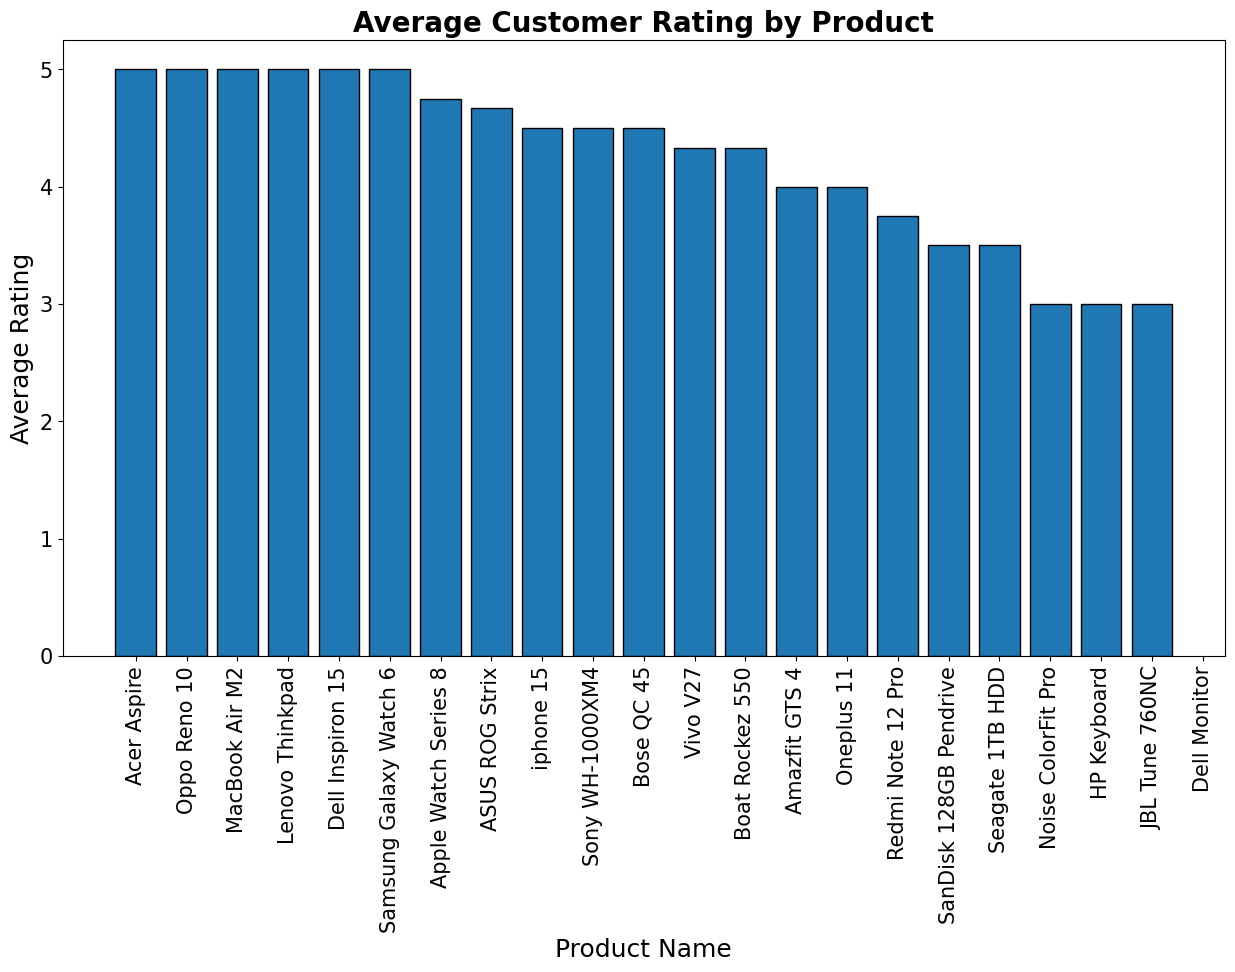

In [18]:
avg_rating=df.groupby("Product_Name")["Rating"].mean().round(2).reset_index().sort_values(by="Rating",ascending=False)
print(avg_rating)
plt.figure(figsize=(15,8))
bars=plt.bar(avg_rating["Product_Name"],avg_rating["Rating"],edgecolor="Black")
plt.title("Average Customer Rating by Product",fontweight="bold",fontsize=20)
plt.xlabel("Product Name",fontsize=18)
plt.ylabel("Average Rating",fontsize=18)
plt.xticks(fontsize=15,rotation=90)
plt.yticks(fontsize=15)
plt.show()

### Q3: Is there a relationship between customer spending and feedback sentiment?

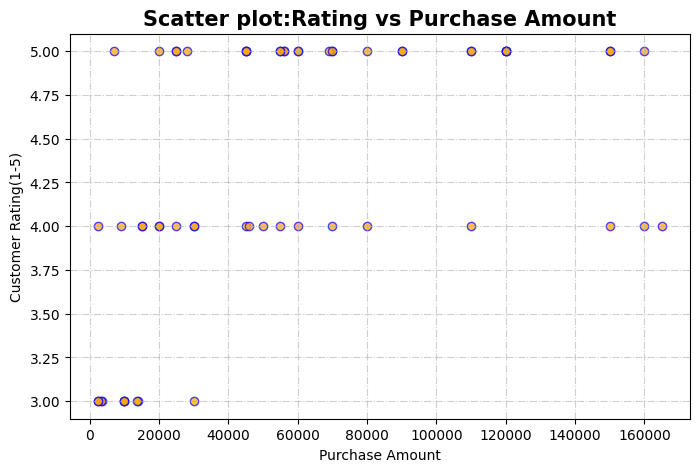

In [4]:
#E)Scatter plot of Customer Ratings vs Purchase Amount
#Analyzes the relationship between how much customers spends and the ratings they give.
df["Purchase Amount"]=df["Quantity"]*df["Unit Price"]
plt.figure(figsize=(8,5))
plt.scatter(df["Purchase Amount"],df["Rating"],color="orange",alpha=0.7,edgecolors="blue")
plt.title("Scatter plot:Rating vs Purchase Amount",fontsize=15,fontweight="bold")
plt.xlabel("Purchase Amount")
plt.ylabel("Customer Rating(1-5)")
plt.grid(True,linestyle="-.",alpha=0.6)
plt.show()

### Q4: Which customer segments contribute the most revenue?

Revenue by Age Group :
Age_Group
18-25     750000
25-30    1299000
30-35    1649700
35-40    1459000
40+       588300
Name: Purchase Amount, dtype: int64


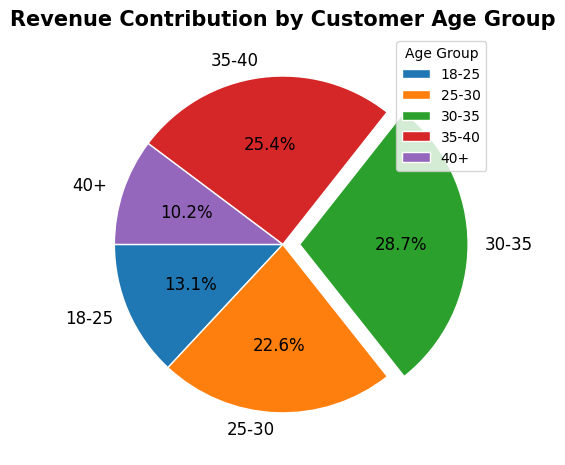

In [81]:
df["Purchase Amount"]=df["Unit Price"]*df["Quantity"]
bins=[18,25,30,35,40,100]
labels=["18-25","25-30","30-35","35-40","40+"]
df["Age_Group"]=pd.cut(df["Age"],bins=bins,labels=labels,include_lowest=True)
age_revenue=df.groupby("Age_Group",observed="False")["Purchase Amount"].sum()
print("Revenue by Age Group :")
print(age_revenue)
plt.figure(figsize=(5,5))
explode=[0,0,0.1,0,0]
plt.pie(
    age_revenue,
    labels=age_revenue.index,autopct="%1.1f%%",
    startangle=180,
    wedgeprops={"edgecolor":"white"},explode=explode,textprops={"fontsize":12}
)
plt.title("Revenue Contribution by Customer Age Group",fontsize=15,fontweight="bold")
plt.tight_layout()
plt.legend(age_revenue.index,title="Age Group")
plt.show()

### Q5. How does company's revenue change over each day?

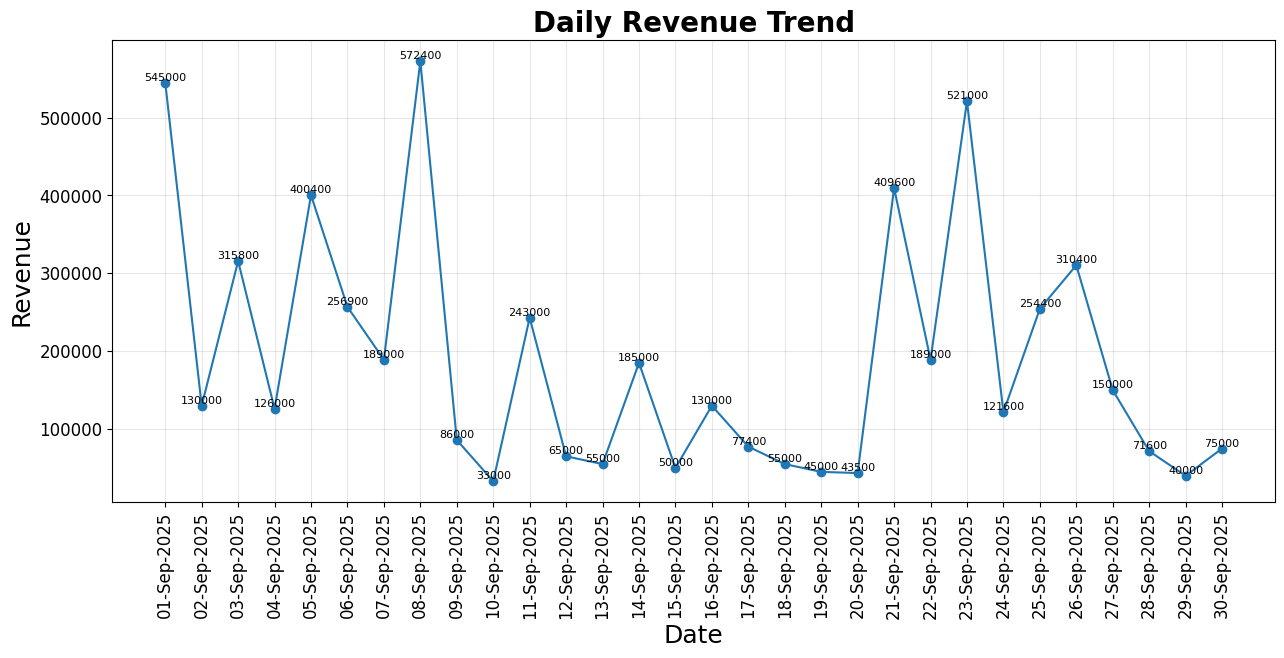

In [75]:
#C)Line chart of the Daily Revenue Trend
#Helps track total revenue generated per day to see overall sales performance.
df["Total_Price"]=df["Quantity"]*df["Unit Price"]
plt.figure(figsize=(15,6))
Daily_Revenue=df.groupby("Purchase_Date")["Total_Price"].sum().reset_index()
Daily_Revenue=Daily_Revenue.sort_values("Purchase_Date")
plt.plot(Daily_Revenue["Purchase_Date"],Daily_Revenue["Total_Price"],marker="o")
plt.title("Daily Revenue Trend",fontsize=20,fontweight="bold")
plt.xlabel("Date",fontsize=18)
plt.ylabel("Revenue",fontsize=18)
plt.xticks(rotation=90,fontsize=12)
plt.yticks(fontsize=12)
for x,y in zip(Daily_Revenue["Purchase_Date"],Daily_Revenue["Total_Price"]):
    plt.text(x,y,str(y),ha="center",va="bottom",fontsize=8)
plt.grid("True",alpha=0.3)
plt.show()
